<a href="https://colab.research.google.com/github/anand57577-lab/Anand_May_Assignment_4_classification/blob/main/Copy_of_customer_churn_classifier(colab).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
import numpy as np

data = pd.read_csv('Customer_churn.csv')
df = pd.DataFrame(data)

In [43]:
df = df.drop('customerID', axis = 1)

In [44]:
for cols in df.columns:
    if set(df[cols].unique()) == {"Yes","No"}:
        print(cols)

Partner
Dependents
PhoneService
PaperlessBilling
Churn


In [45]:
import pandas as pd
pd.set_option('display.max_columns',None)


for col in df.columns[0:21]:
    print(col," ",df[col].unique(),"\n")

gender   ['Female' 'Male'] 

SeniorCitizen   [0 1] 

Partner   ['Yes' 'No'] 

Dependents   ['No' 'Yes'] 

tenure   [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39] 

PhoneService   ['No' 'Yes'] 

MultipleLines   ['No phone service' 'No' 'Yes'] 

InternetService   ['DSL' 'Fiber optic' 'No'] 

OnlineSecurity   ['No' 'Yes' 'No internet service'] 

OnlineBackup   ['Yes' 'No' 'No internet service'] 

DeviceProtection   ['No' 'Yes' 'No internet service'] 

TechSupport   ['No' 'Yes' 'No internet service'] 

StreamingTV   ['No' 'Yes' 'No internet service'] 

StreamingMovies   ['No' 'Yes' 'No internet service'] 

Contract   ['Month-to-month' 'One year' 'Two year'] 

PaperlessBilling   ['Yes' 'No'] 

PaymentMethod   ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)'] 

MonthlyCharges  

In [46]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
for cols in ['gender','Partner','Dependents','PhoneService','PaperlessBilling', 'Churn']:
    df[cols] = lb.fit_transform(df[cols])


df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [47]:
df.dtypes


,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [48]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop = 'first')
ohe_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod',]
encoded = ohe.fit_transform(df[ohe_cols])
encoded_df = pd.DataFrame(encoded.toarray(), columns=ohe.get_feature_names_out(ohe_cols))
df = pd.concat([df.drop(ohe_cols, axis=1).reset_index(drop=True), encoded_df.reset_index(drop=True)],axis=1)


In [49]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = "coerce")

In [50]:
import pandas as pd
pd.set_option('display.max_columns',None)


for col in df.columns[12:21]:
    print(col," ",df[col].unique(),"\n")

InternetService_Fiber optic   [0. 1.] 

InternetService_No   [0. 1.] 

OnlineSecurity_No internet service   [0. 1.] 

OnlineSecurity_Yes   [0. 1.] 

OnlineBackup_No internet service   [0. 1.] 

OnlineBackup_Yes   [1. 0.] 

DeviceProtection_No internet service   [0. 1.] 

DeviceProtection_Yes   [0. 1.] 

TechSupport_No internet service   [0. 1.] 



In [51]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
PaperlessBilling,0
MonthlyCharges,0
TotalCharges,11
Churn,0


In [52]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())
df.TotalCharges.isnull().sum()

np.int64(0)

In [53]:
df.shape

(7043, 31)

In [54]:
from sklearn.model_selection import train_test_split
x = df.drop('Churn', axis = 1)
y = df['Churn']

In [55]:
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=42, test_size=0.2)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 30)
(1409, 30)
(5634,)
(1409,)


In [56]:
from sklearn.preprocessing import StandardScaler
se = StandardScaler()
x_train = pd.DataFrame(se.fit_transform(x_train))
x_test = pd.DataFrame(se.transform(x_test))

In [57]:
#Logistic Refression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=2000, solver = 'saga')
lr_fit  = lr.fit(x_train,y_train)
lr_pred = lr_fit.predict(x_test)



0.8211497515968772

 Classification_report 
 
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

 
 confusion_matrix 
 [[935 101]
 [151 222]]

 AUC SCOREC : 0.8619729936754066


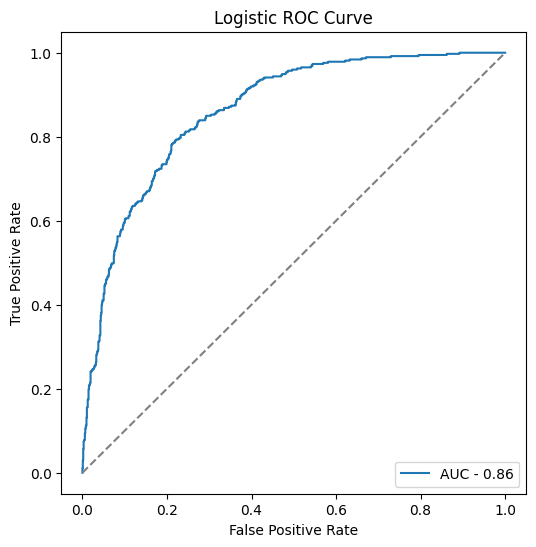

In [58]:


# accuracy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
score  = accuracy_score(y_test, lr_pred)
print(score)

#classification_report

print("\n Classification_report \n \n",classification_report(y_test, lr_pred))

#confusion_Metric

cm = confusion_matrix(y_test,lr_pred)
print(" \n confusion_matrix \n",cm)

#ROC-AUC curve

from sklearn.metrics import roc_auc_score, roc_curve

probs = lr_fit.predict_proba(x_test)[:,1]

auc = roc_auc_score(y_test,probs)
print("\n AUC SCOREC :",auc)

fpr, tpr, thresholds = roc_curve(y_test,probs)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr,label = f"AUC - {auc:.2f}" )
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # diagonal line for random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic ROC Curve")
plt.legend(loc="lower right")
plt.show()



In [59]:
from sklearn.tree import DecisionTreeClassifier

dtc_model = DecisionTreeClassifier(criterion='entropy',max_depth = 5, min_samples_split = 10, min_samples_leaf = 10,random_state=42)
fit_dtc = dtc_model.fit(x_train,y_train)
pred_dtc = fit_dtc.predict(x_test)

Accuracy:  0.7913413768630234

 Classification_report 
 
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1036
           1       0.63      0.51      0.57       373

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

 
 confusion_matrix 
 [[924 112]
 [182 191]]

 AUC SCOREC : 0.8387927375863033


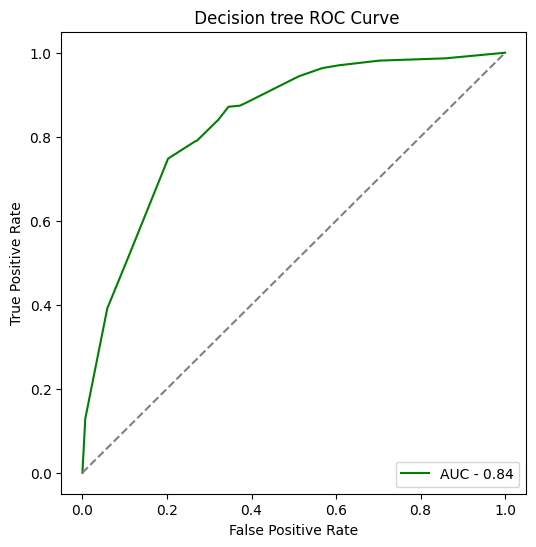

In [60]:

# accuracy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
score  = accuracy_score(y_test, pred_dtc)
print("Accuracy: ",score)

#classification_report

print("\n Classification_report \n \n",classification_report(y_test, pred_dtc))

#confusion_Metric

cm = confusion_matrix(y_test,pred_dtc)
print(" \n confusion_matrix \n",cm)

#ROC-AUC curve

from sklearn.metrics import roc_auc_score, roc_curve

probs = fit_dtc.predict_proba(x_test)[:,1]

auc = roc_auc_score(y_test,probs)
print("\n AUC SCOREC :",auc)

fpr, tpr, thresholds = roc_curve(y_test,probs)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr,label = f"AUC - {auc:.2f}" , color = 'green')
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # diagonal line for random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(" Decision tree ROC Curve")
plt.legend(loc="lower right")
plt.show()



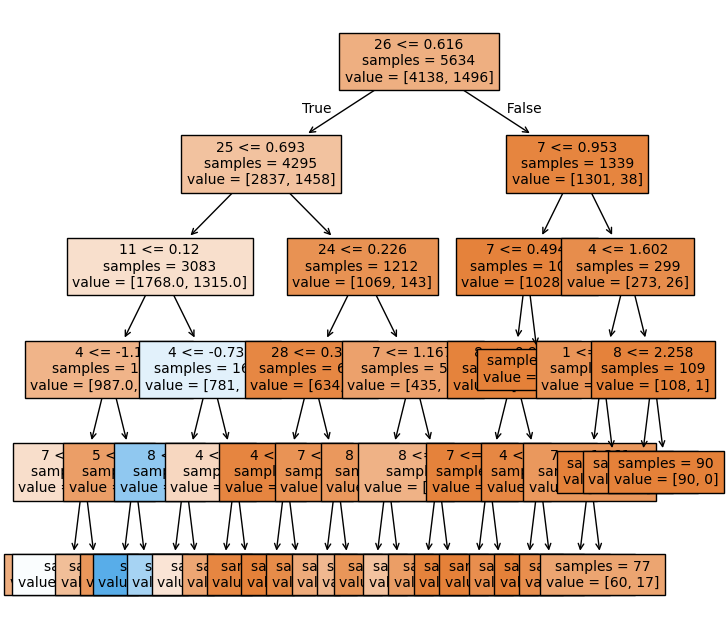

In [20]:
from sklearn import tree

plt.figure(figsize=(8,8))
tree.plot_tree(dtc_model, filled=True, feature_names=x_train.columns, fontsize=10, impurity=False)
plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state = 42, n_estimators = 200,max_depth=9,
    min_samples_split=10,
    min_samples_leaf=5,


)
rfc_fit = rfc.fit(x_train,y_train)
rfc_pred = rfc_fit.predict(x_test)

Accuracy:  0.8105039034776437
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.70      0.50      0.58       373

    accuracy                           0.81      1409
   macro avg       0.77      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409

 
 confusion_matrix 
 [[955  81]
 [186 187]]

 AUC SCOREC : 0.865399246431418


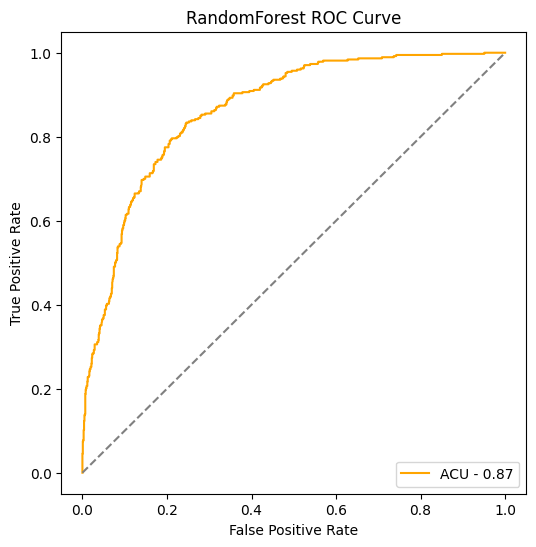

In [22]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
score = accuracy_score(y_test,rfc_pred)
print("Accuracy: ",score )

print(classification_report(y_test,rfc_pred))

cm = confusion_matrix(y_test,rfc_pred)
print(" \n confusion_matrix \n",cm)

probs  = rfc_fit.predict_proba(x_test)[:,1]
auc = roc_auc_score(y_test,probs)
print("\n AUC SCOREC :",auc)

fpr,tpr,thresholds = roc_curve(y_test,probs)

plt.figure(figsize = (6,6))
plt.plot(fpr,tpr, label = f"ACU - {auc:.2f}", color = 'orange')
plt.plot([0,1],[0,1] , linestyle = '--', color = 'grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RandomForest ROC Curve")
plt.legend(loc = "lower right")
plt.show()

In [23]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn_fit = knn.fit(x_train,y_train)
knn_pred = knn_fit.predict(x_test)

Accuracy:  0.7714691270404542
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1036
           1       0.58      0.52      0.55       373

    accuracy                           0.77      1409
   macro avg       0.70      0.69      0.70      1409
weighted avg       0.76      0.77      0.77      1409

 
 confusion_matrix 
 [[893 143]
 [179 194]]

 AUC SCOREC : 0.790206713799207


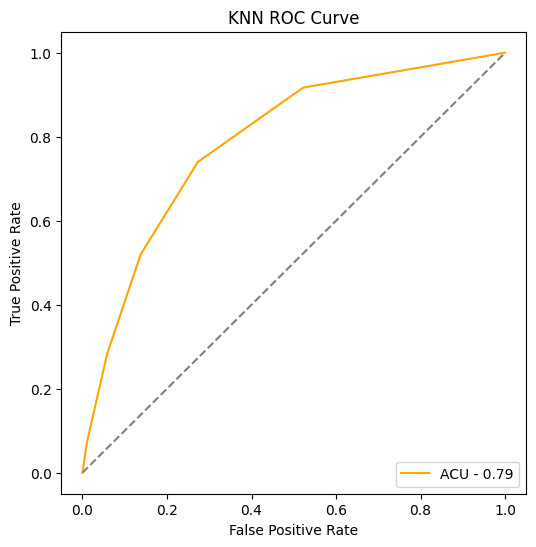

In [24]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
score = accuracy_score(y_test,knn_pred)
print("Accuracy: ",score )

print(classification_report(y_test,knn_pred))

cm = confusion_matrix(y_test,knn_pred)
print(" \n confusion_matrix \n",cm)

probs = knn_fit.predict_proba(x_test)[:,1]
auc = roc_auc_score(y_test,probs)
print("\n AUC SCOREC :",auc)

fpr,tpr,thresholds = roc_curve(y_test,probs)
plt.figure(figsize = (6,6))
plt.plot(fpr,tpr, label = f"ACU - {auc:.2f}", color = 'orange')
plt.plot([0,1],[0,1] , linestyle = '--', color = 'grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend(loc = "lower right")
plt.show()

In [25]:
from sklearn.svm import SVC
svc = SVC(kernel='linear' ,random_state = 42,gamma = 'scale' , probability = True)
svc_fit = svc.fit(x_train,y_train)
svc_pred = svc_fit.predict(x_test)

Accuracy:  0.8211497515968772
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

 
 confusion_matrix 
 [[935 101]
 [151 222]]

 AUC SCOREC : 0.8526064363865973


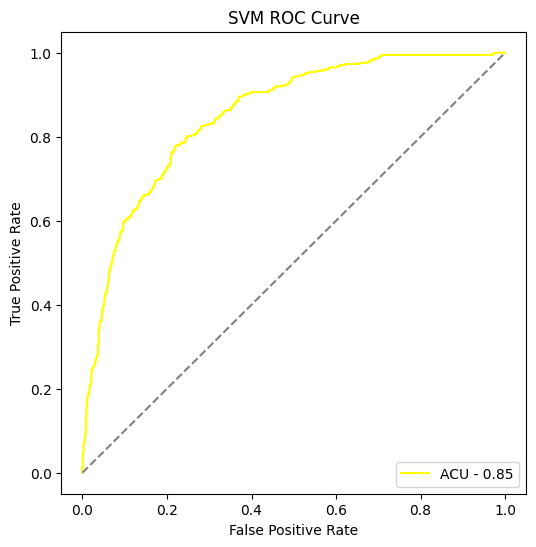

In [26]:



from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
score = accuracy_score(y_test,svc_pred)
print("Accuracy: ",score )

print(classification_report(y_test,svc_pred))

cm = confusion_matrix(y_test,svc_pred)
print(" \n confusion_matrix \n",cm)

probs = svc_fit.predict_proba(x_test)[:,1]
auc = roc_auc_score(y_test,probs)
print("\n AUC SCOREC :",auc)

fpr,tpr,thresholds = roc_curve(y_test,probs)
plt.figure(figsize = (6,6))
plt.plot(fpr,tpr, label = f"ACU - {auc:.2f}", color = 'yellow')
plt.plot([0,1],[0,1] , linestyle = '--', color = 'grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend(loc = "lower right")
plt.show()

In [27]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_fit  = nb.fit(x_train,y_train)
nb_pred  =  nb_fit.predict(x_test)



Accuracy:  0.6657203690560681
              precision    recall  f1-score   support

           0       0.94      0.58      0.72      1036
           1       0.44      0.89      0.59       373

    accuracy                           0.67      1409
   macro avg       0.69      0.74      0.65      1409
weighted avg       0.81      0.67      0.68      1409

 
 confusion_matrix 
 [[605 431]
 [ 40 333]]

 AUC SCOREC : 0.8377278561594915


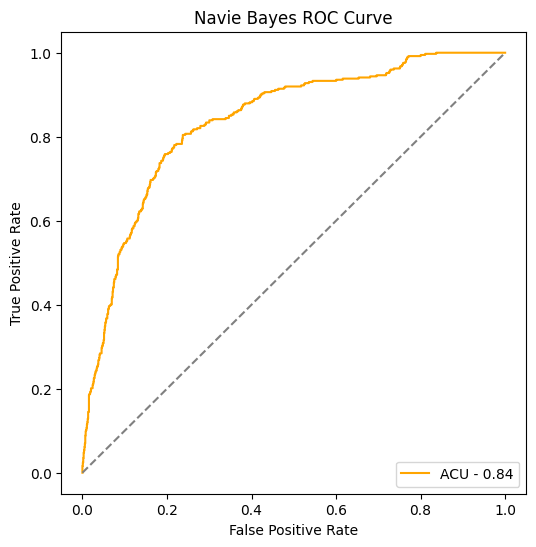

In [28]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
score = accuracy_score(y_test,nb_pred)
print("Accuracy: ",score )

print(classification_report(y_test,nb_pred))

cm = confusion_matrix(y_test,nb_pred)
print(" \n confusion_matrix \n",cm)

probs = nb_fit.predict_proba(x_test)[:,1]
auc = roc_auc_score(y_test,probs)
print("\n AUC SCOREC :",auc)

fpr,tpr,thresholds = roc_curve(y_test,probs)
plt.figure(figsize = (6,6))
plt.plot(fpr,tpr, label = f"ACU - {auc:.2f}", color = 'orange')
plt.plot([0,1],[0,1] , linestyle = '--', color = 'grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Navie Bayes ROC Curve")
plt.legend(loc = "lower right")
plt.show()

In [29]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb_fit = gb.fit(x_train,y_train)
gb_pred = gb.predict(x_test)

Accuracy Score : 0.8119233498935415
classification Report : 
               precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


 confusion matrix :
 [[940  96]
 [169 204]]


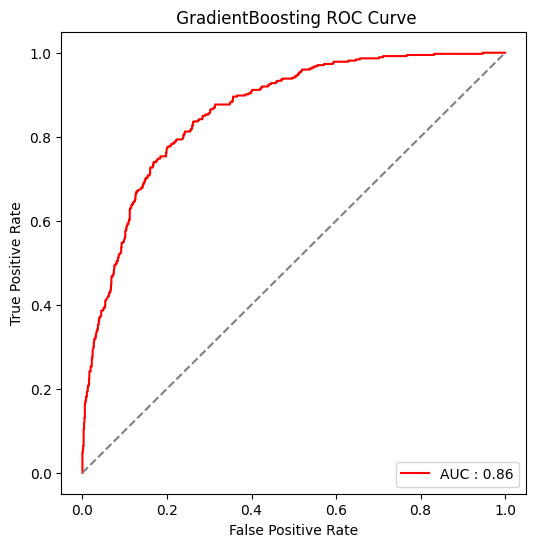

In [30]:


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score,roc_curve

print("Accuracy Score :", accuracy_score(y_test,gb_pred))

print("classification Report : \n",classification_report(y_test,gb_pred))

print("\n confusion matrix :\n",confusion_matrix(y_test,gb_pred))

proba = gb_fit.predict_proba(x_test)[:, 1]
auc = roc_auc_score(y_test, proba)
auc

fpr, tpr, thresholds = roc_curve(y_test, proba)
plt.figure(figsize = (6,6))
plt.plot(fpr,tpr, label = f"AUC : {auc:.2f}", color = 'red')
plt.plot([0,1] , [0,1], linestyle = '--' , color = 'grey' )
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(" GradientBoosting ROC Curve")
plt.legend(loc = "lower right")
plt.show()

In [31]:
from sklearn.ensemble import AdaBoostClassifier
ad = AdaBoostClassifier()
ad_fit = ad.fit(x_train, y_train)
ad_pred = ad_fit.predict(x_test)

Accuracy Score : 0.8140525195173882
classification Report : 
               precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.69      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.74      1409
weighted avg       0.81      0.81      0.81      1409


 confusion matrix :
 [[942  94]
 [168 205]]


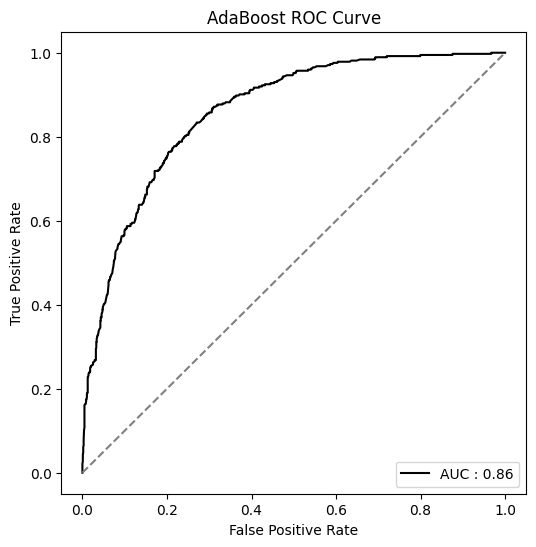

In [32]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score,roc_curve

print("Accuracy Score :", accuracy_score(y_test,ad_pred))

print("classification Report : \n",classification_report(y_test,ad_pred))

print("\n confusion matrix :\n",confusion_matrix(y_test,ad_pred))

proba = ad_fit.predict_proba(x_test)[:, 1]
auc = roc_auc_score(y_test, proba)
auc

fpr, tpr, thresholds = roc_curve(y_test, proba)
plt.figure(figsize = (6,6))
plt.plot(fpr,tpr, label = f"AUC : {auc:.2f}", color = 'black')
plt.plot([0,1] , [0,1], linestyle = '--' , color = 'grey' )
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AdaBoost ROC Curve")
plt.legend(loc = "lower right")
plt.show()

In [33]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(x_train, y_train)

xgb_pred = xgb.predict(x_test)

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))

Accuracy: 0.8048261178140526

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.66      0.54      0.59       373

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



Accuracy Score : 0.8048261178140526
classification Report : 
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.66      0.54      0.59       373

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409


 confusion matrix :
 [[942  94]
 [168 205]]


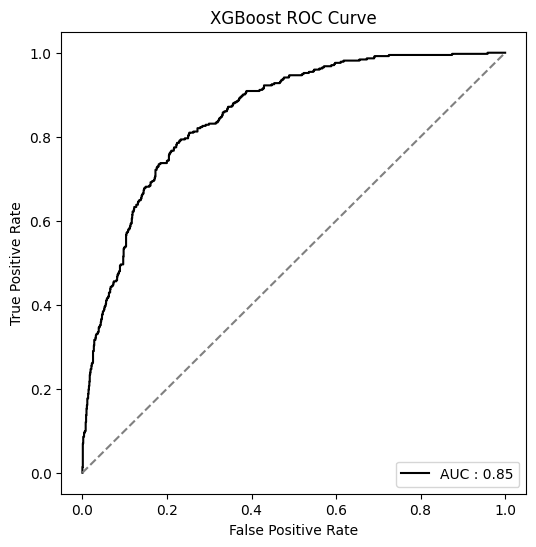

In [34]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score,roc_curve

print("Accuracy Score :", accuracy_score(y_test,xgb_pred))

print("classification Report : \n",classification_report(y_test,xgb_pred))

print("\n confusion matrix :\n",confusion_matrix(y_test,ad_pred))

proba = xgb.predict_proba(x_test)[:, 1]
auc = roc_auc_score(y_test, proba)
auc

fpr, tpr, thresholds = roc_curve(y_test, proba)
plt.figure(figsize = (6,6))
plt.plot(fpr,tpr, label = f"AUC : {auc:.2f}", color = 'black')
plt.plot([0,1] , [0,1], linestyle = '--' , color = 'grey' )
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend(loc = "lower right")
plt.show()

In [35]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [36]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    verbose=0,
    random_state=42
)

cat.fit(x_train, y_train)

cat_pred = cat.predict(x_test)

print("Accuracy:", accuracy_score(y_test, cat_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, cat_pred))

Accuracy: 0.8069552874378992

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.53      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



Accuracy Score : 0.8069552874378992
classification Report : 
               precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.53      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409


 confusion matrix :
 [[942  94]
 [168 205]]


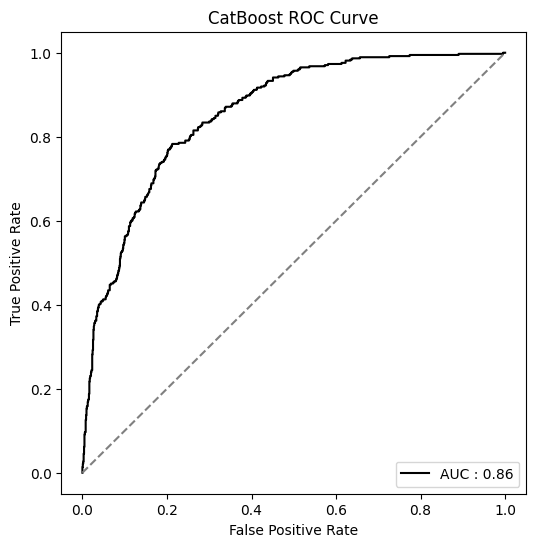

In [37]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score,roc_curve

print("Accuracy Score :", accuracy_score(y_test,cat_pred))

print("classification Report : \n",classification_report(y_test,cat_pred))

print("\n confusion matrix :\n",confusion_matrix(y_test,ad_pred))

proba = cat.predict_proba(x_test)[:, 1]
auc = roc_auc_score(y_test, proba)
auc

fpr, tpr, thresholds = roc_curve(y_test, proba)
plt.figure(figsize = (6,6))
plt.plot(fpr,tpr, label = f"AUC : {auc:.2f}", color = 'black')
plt.plot([0,1] , [0,1], linestyle = '--' , color = 'grey' )
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CatBoost ROC Curve")
plt.legend(loc = "lower right")
plt.show()

In [38]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": lr,
    "Decision Tree": dtc_model,
    "Random Forest": rfc,
    "KNN": knn,
    "Naive Bayes": nb,
    "SVM": svc,
    "GradientBoostingClassifier": gb,
    "AdaBoostClassifier": ad,
    "CatBoostClassifier": cat,
    "XGBClassifier": xgb
}


results = {}

for name, model in models.items():

    model.fit(x_train, y_train)

    pred = model.predict(x_test)

    acc = accuracy_score(y_test, pred)

    results[name] = acc

for model, score in results.items():
    print(model, ":", round(score*100,2), "%")

Logistic Regression : 82.11 %
Decision Tree : 79.13 %
Random Forest : 81.05 %
KNN : 77.15 %
Naive Bayes : 66.57 %
SVM : 82.11 %
GradientBoostingClassifier : 81.19 %
AdaBoostClassifier : 81.41 %
CatBoostClassifier : 80.7 %
XGBClassifier : 80.48 %


In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
models = {
    "Logistic Regression": lr,
    "Decision Tree": dtc_model,
    "Random Forest": rfc,
    "KNN": knn,
    "Naive Bayes": nb,
    "SVM": svc,
    "GradientBoostingClassifier": gb,
    "AdaBoostClassifier": ad,
    "CatBoostClassifier": cat,
    "XGBClassifier": xgb
}

results = []

for name, model in models.items():

    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
)

print(results_df)

                    Algorithm  Accuracy  Precision    Recall  F1-Score
0         Logistic Regression  0.821150   0.687307  0.595174  0.637931
5                         SVM  0.821150   0.687307  0.595174  0.637931
7          AdaBoostClassifier  0.814053   0.685619  0.549598  0.610119
6  GradientBoostingClassifier  0.811923   0.680000  0.546917  0.606241
9               XGBClassifier  0.804826   0.662252  0.536193  0.592593
8          CatBoostClassifier  0.806955   0.673540  0.525469  0.590361
4                 Naive Bayes  0.665720   0.435864  0.892761  0.585752
2               Random Forest  0.810504   0.697761  0.501340  0.583463
1               Decision Tree  0.791341   0.630363  0.512064  0.565089
3                         KNN  0.771469   0.575668  0.520107  0.546479


In [40]:
#asceding  order of list results_df
results_df.sort_values(by = 'Accuracy', ascending=False)

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.821150,0.687307,0.595174,0.637931
5,SVM,0.821150,0.687307,0.595174,0.637931
7,AdaBoostClassifier,0.814053,0.685619,0.549598,0.610119
6,GradientBoostingClassifier,0.811923,0.680000,0.546917,0.606241
2,Random Forest,0.810504,0.697761,0.501340,0.583463
8,CatBoostClassifier,0.806955,0.673540,0.525469,0.590361
9,XGBClassifier,0.804826,0.662252,0.536193,0.592593
1,Decision Tree,0.791341,0.630363,0.512064,0.565089
3,KNN,0.771469,0.575668,0.520107,0.546479
4,Naive Bayes,0.665720,0.435864,0.892761,0.585752


--- MODEL METRICS SUMMARY ---


,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.821150,0.687307,0.595174,0.637931
5,SVM,0.821150,0.687307,0.595174,0.637931
7,AdaBoostClassifier,0.814053,0.685619,0.549598,0.610119
6,GradientBoostingClassifier,0.811923,0.680000,0.546917,0.606241
9,XGBClassifier,0.804826,0.662252,0.536193,0.592593
8,CatBoostClassifier,0.806955,0.673540,0.525469,0.590361
4,Naive Bayes,0.665720,0.435864,0.892761,0.585752
2,Random Forest,0.810504,0.697761,0.501340,0.583463
1,Decision Tree,0.791341,0.630363,0.512064,0.565089
3,KNN,0.771469,0.575668,0.520107,0.546479


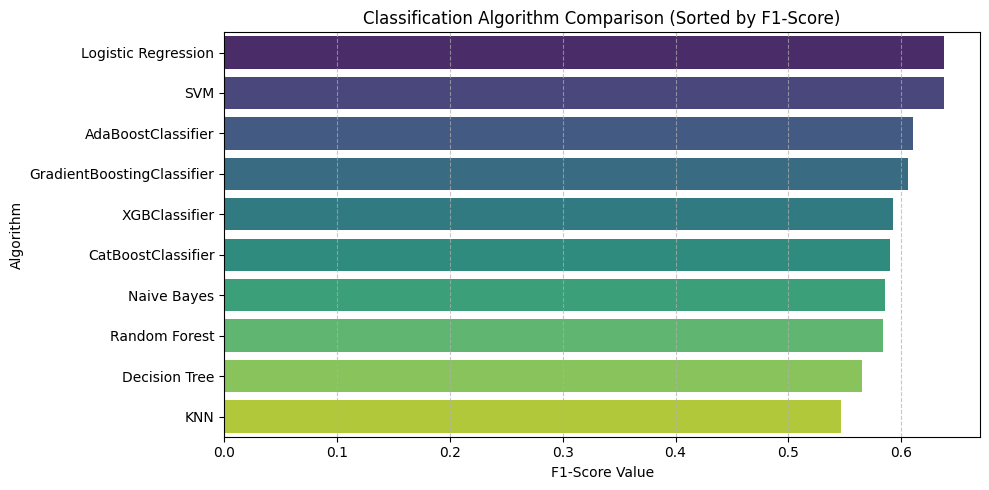

In [61]:
print("--- MODEL METRICS SUMMARY ---")
display(results_df.style.background_gradient(cmap='Blues', subset=['Accuracy', 'F1-Score']))

# 2. Plot F1-Scores for visual comparison
plt.figure(figsize=(10, 5))
# Updated plotting line to clear the warning
sns.barplot(x="F1-Score", y="Algorithm", data=results_df, hue="Algorithm", palette="viridis", legend=False)
plt.title("Classification Algorithm Comparison (Sorted by F1-Score)")
plt.xlabel("F1-Score Value")
plt.ylabel("Algorithm")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()